# 🧠 Klasifikasi Citra Tumor Otak Menggunakan Support Vector Machine (SVM)

**Mata Kuliah :** Computer Vision  
**Nama :** Fadhli Ilham Nafi'an Yuswono  
**NIM :** 2318001  

---

### 🔗 Dataset :
* **Dataset Raw Citra MRI :** [Kaggle - Brain MRI Images for Brain Tumor Detection](https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection) (Terdiri dari 253 citra: 155 Yes/Tumor, 98 No/Sehat)

---
**Tujuan Proyek :** Proyek ini bertujuan mengklasifikasikan citra MRI otak menjadi dua kategori: **Tumor (Yes)** dan **Sehat (No)** menggunakan **Support Vector Machine (SVM)** berdasarkan fitur intensitas warna, bentuk (area/perimeter), dan tekstur GLCM.

### 1️⃣ Import Library & Koneksi Dataset

In [17]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import shannon_entropy
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from google.colab import drive

plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")

drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Study/Semester 6/Computer Vision/UTS/Dataset/brain_tumor_dataset'
categories = ['no', 'yes']
print("✅ Drive berhasil tersambung!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive berhasil tersambung!


### 2️⃣ Ekstraksi Fitur (Warna, Tekstur, dan Bentuk)
Untuk mendapatkan hasil analisis yang kaya dan representatif, sistem ini mengekstraksi 3 jenis fitur sekaligus dari setiap citra yairu:
1. **Fitur Warna/Intensitas :** menghitung rata-rata kecerahan (*Mean*) dan standar deviasi (*Std Dev*) piksel
2. **Fitur Bentuk (Morfologi) :** menggunakan *Thresholding* dan *Contours* untuk menghitung luas area massa (*Area*) dan keliling luar objek (*Perimeter*)
3. **Fitur Tekstur (GLCM) :** mengekstraksi *Contrast*, *Energy*, dan *Homogeneity* untuk mendeteksi tingkat kekasaran dan keseragaman jaringan

In [18]:
data_features = []
labels = []
print("🔄 Memproses ekstraksi fitur Warna, Tekstur, dan Bentuk... Mohon tunggu.")

for category in categories:
    folder_path = os.path.join(base_path, category)
    label = categories.index(category)

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path, 0) # Grayscale

        if img is not None:
            img = cv2.resize(img, (256, 256))

            # fitur warna
            mean_intensity = np.mean(img)
            std_intensity = np.std(img)

            # fitur tekstur (GLCM)
            glcm = graycomatrix(img, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)
            contrast = graycoprops(glcm, 'contrast')[0, 0]
            energy = graycoprops(glcm, 'energy')[0, 0]
            homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

            # fitur bentuk (Morfologi Contours)
            # Thresholding untuk mencari bentuk massa putih u/ otak/tumor
            _, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            area = 0
            perimeter = 0
            # Ambil contour terbesar
            if len(contours) > 0:
                cnt = max(contours, key=cv2.contourArea)
                area = cv2.contourArea(cnt)
                perimeter = cv2.arcLength(cnt, True)

            # Gabungkan ke dalam list
            data_features.append([mean_intensity, std_intensity, area, perimeter, contrast, energy, homogeneity])
            labels.append(label)

# Simpan ke DataFrame
kolom_fitur = ['Mean_Intensitas', 'Std_Intensitas', 'Area', 'Perimeter', 'Contrast', 'Energy', 'Homogeneity']
df = pd.DataFrame(data_features, columns=kolom_fitur)
df['Label'] = labels

print(f"✅ Berhasil mengekstraksi {len(df)} citra dengan Kombinasi 7 Fitur!")
df.head()

🔄 Memproses ekstraksi fitur Warna, Tekstur, dan Bentuk... Mohon tunggu.
✅ Berhasil mengekstraksi 253 citra dengan Kombinasi 7 Fitur!


,Mean_Intensitas,Std_Intensitas,Area,Perimeter,Contrast,Energy,Homogeneity,Label
0,30.529587,47.663105,24466.0,650.558436,2094.551544,0.387339,0.545106,0
1,63.135803,47.426645,310.0,328.391916,1154.247463,0.169453,0.283244,0
2,35.038589,46.143573,1433.5,1073.075244,1618.753797,0.452405,0.489674,0
3,49.114792,42.415745,32.5,42.041630,568.596520,0.068616,0.221826,0
4,76.433258,85.595387,33625.5,696.683327,3494.752117,0.394766,0.441173,0


### 🧮 Perhitungan Manual Ekstraksi Fitur

**A. Mean Intensity (Warna)**
Menghitung rata-rata tingkat kecerahan piksel pada citra grayscale:
$$Mean = \frac{1}{M \times N} \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x,y)$$

**B. GLCM Contrast (Tekstur)**
Mengukur variasi intensitas antar piksel bertetangga untuk mendeteksi tekstur jaringan:
$$Contrast = \sum_{i,j=0}^{N-1} P_{i,j}(i-j)^2$$
**C. Area (Bentuk/Morfologi)**
Menghitung luas area massa dengan menjumlahkan total piksel objek (bernilai putih/1) pada citra hasil *thresholding*:
$$Area = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} I(x,y)$$
*(Di mana $I(x,y)$ bernilai 1 jika piksel adalah bagian dari objek, dan 0 jika *background*)*

Perbandingkan citra asli dan citra hasil Thresholding (sebelum dihitung Area-nya)

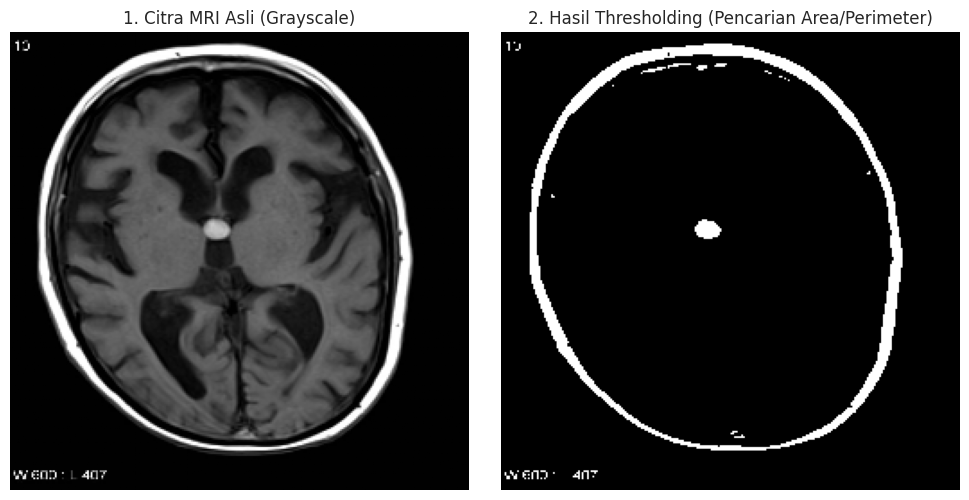

In [19]:
# Visualisasi Proses Ekstraksi Bentuk (Thresholding)
import matplotlib.pyplot as plt

# Mengambil satu sampel citra acak dari folder 'yes' (Tumor)
sample_img_path = os.path.join(base_path, 'yes', os.listdir(os.path.join(base_path, 'yes'))[0])
img_sample = cv2.imread(sample_img_path, 0)
img_sample = cv2.resize(img_sample, (256, 256))

# Proses thresholding seperti di loop ekstraksi fitur
_, thresh_sample = cv2.threshold(img_sample, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_sample, cmap='gray')
plt.title("1. Citra MRI Asli (Grayscale)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(thresh_sample, cmap='gray')
plt.title("2. Hasil Thresholding (Pencarian Area/Perimeter)")
plt.axis('off')

plt.tight_layout()
plt.show()

### 3️⃣ Exploratory Data Analysis (EDA) - Distribusi Fitur
sebelum melatih model, kita bisa lihat bagaimana persebaran data tekstur antara citra Sehat (0) dan Tumor (1). Dibawah ini kita bisa melihat fitur mana yang memiliki perbedaan distribusi yg paling mencolok

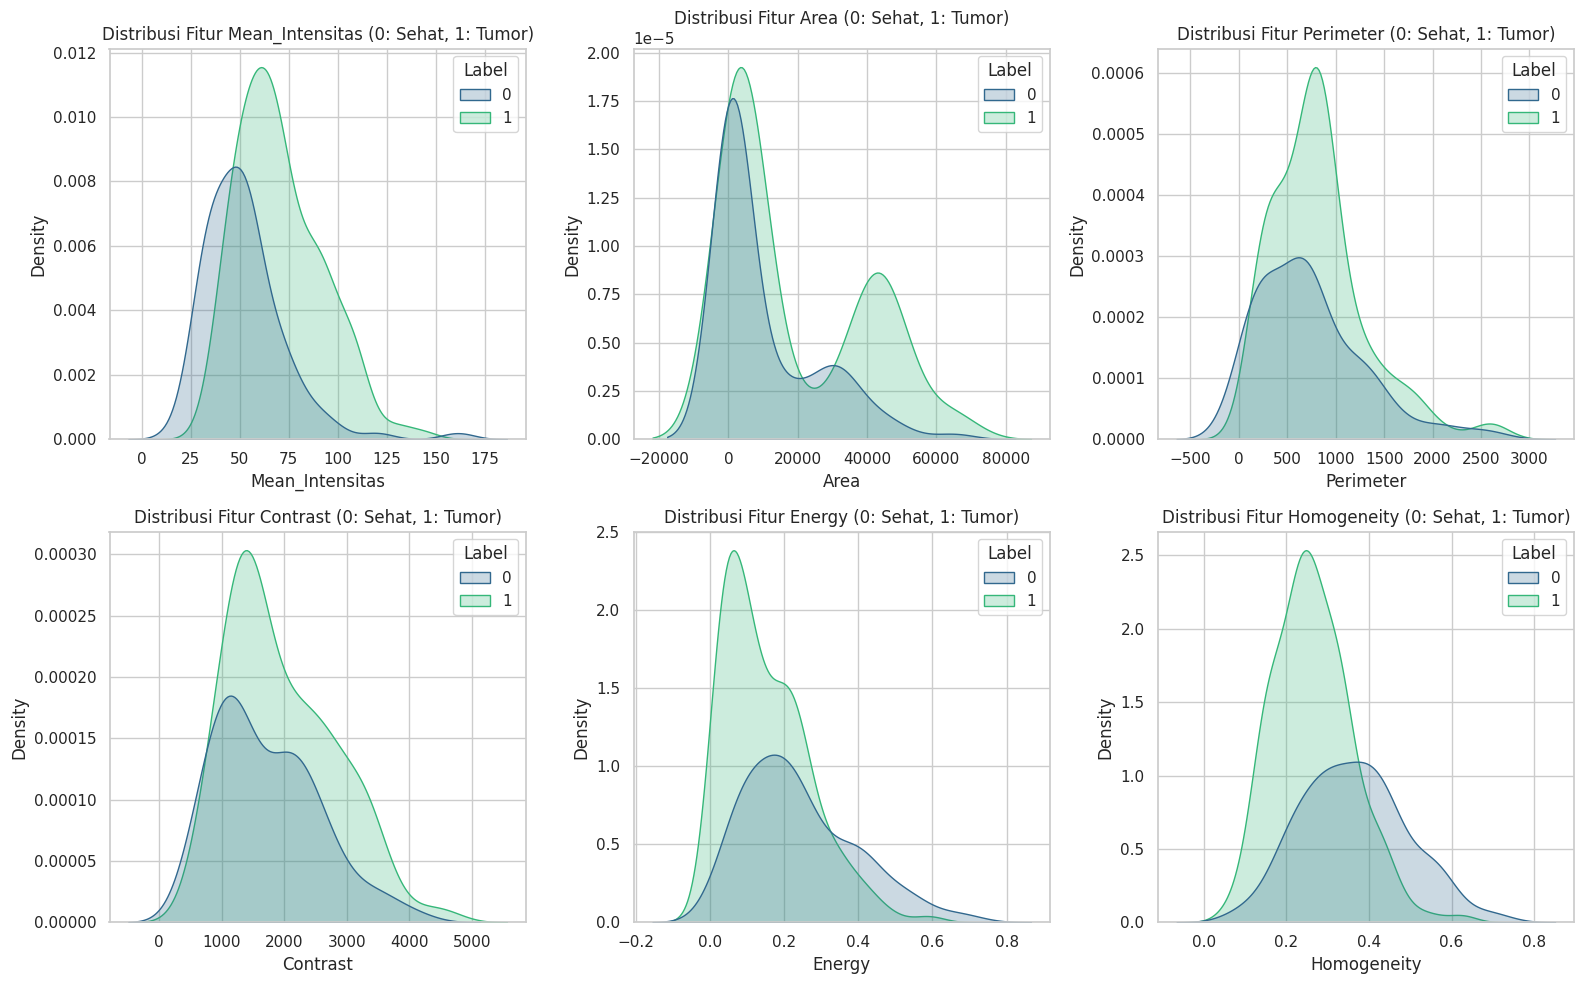

In [20]:
plt.figure(figsize=(16, 10))
# Tampilkan 6 fitur yang mewakili kombinasi bentuk, warna, dan tekstur
features_plot = ['Mean_Intensitas', 'Area', 'Perimeter', 'Contrast', 'Energy', 'Homogeneity']

for i, col in enumerate(features_plot):
    plt.subplot(2, 3, i+1)
    sns.kdeplot(data=df, x=col, hue='Label', fill=True, palette='viridis')
    plt.title(f'Distribusi Fitur {col} (0: Sehat, 1: Tumor)')

plt.tight_layout()
plt.show()

Correlation Heatmap

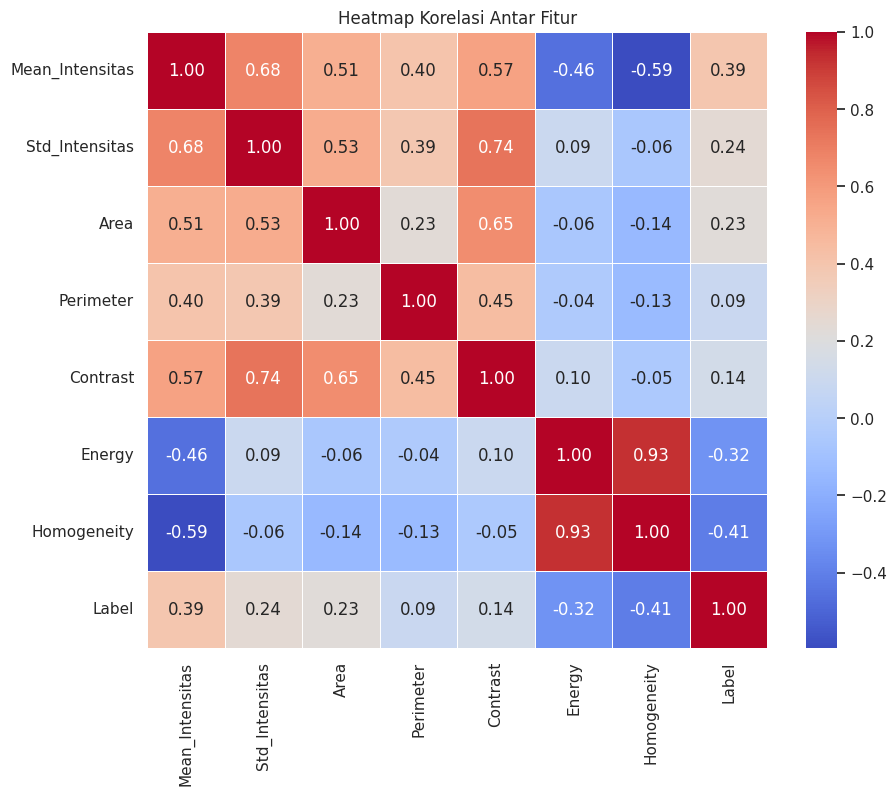

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

Pairplot / Scatter Plot 2D

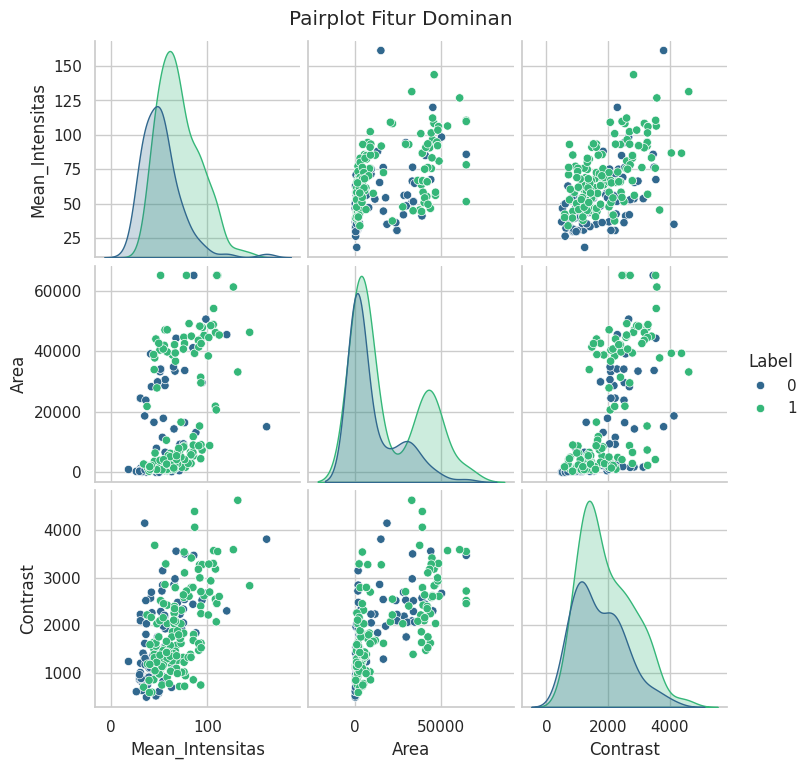

In [22]:
# Menampilkan hubungan 3 fitur terpenting dengan Label
sns.pairplot(df[['Mean_Intensitas', 'Area', 'Contrast', 'Label']], hue='Label', palette='viridis')
plt.suptitle("Pairplot Fitur Dominan", y=1.02)
plt.show()

### 4️⃣ Preprocessing (Split & Scaling Data)
data yang sudah diekstraksi tadi kita bagi menjadi dua bagian: **80% untuk Training** dan **20% untuk Testing**.
Kita juga menerapkan `StandardScaler` agar seluruh fitur punya rentang skala yang seragam, sehingga algoritma SVM dapat bekerja secara optimal tanpa bias pada fitur yang nilainya terlalu besar

In [23]:
X = df.drop('Label', axis=1)
y = df['Label']

# Split data 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standarisasi data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data telah dibagi dan di-scaling!")

✅ Data telah dibagi dan di-scaling!


### 5️⃣ Training Model SVM (*Support Vector Machine*)
model SVM ini kita latih menggunakan `kernel='linear'`. Pendekatan linear dipilih karena sangat efektif untuk mencari *hyperplane* (garis batas pemisah) yang paling optimal pada dataset medis berukuran menengah dengan jumlah fitur yang padat

In [24]:
# Menggunakan Kernel Linear untuk klasifikasi optimal
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)
print(f"🎯 Akurasi Model: {accuracy_score(y_test, y_pred)*100:.2f}%")

🎯 Akurasi Model: 76.47%


### 6️⃣ Evaluasi Performa Model
u/ memastikan model tidak asal menebak, kita mengevaluasinya menggunakan dua metrik yaitu:
1. **Confusion Matrix :** melihat detail jumlah tebakan yang benar (True Positive/Negative) dan yang meleset
2. **ROC Curve (AUC) :** mengukur kemampuan model dalam membedakan kelas. Semakin mendekati angka 1.00, semakin sempurna model memisahkan data Tumor dan Sehat

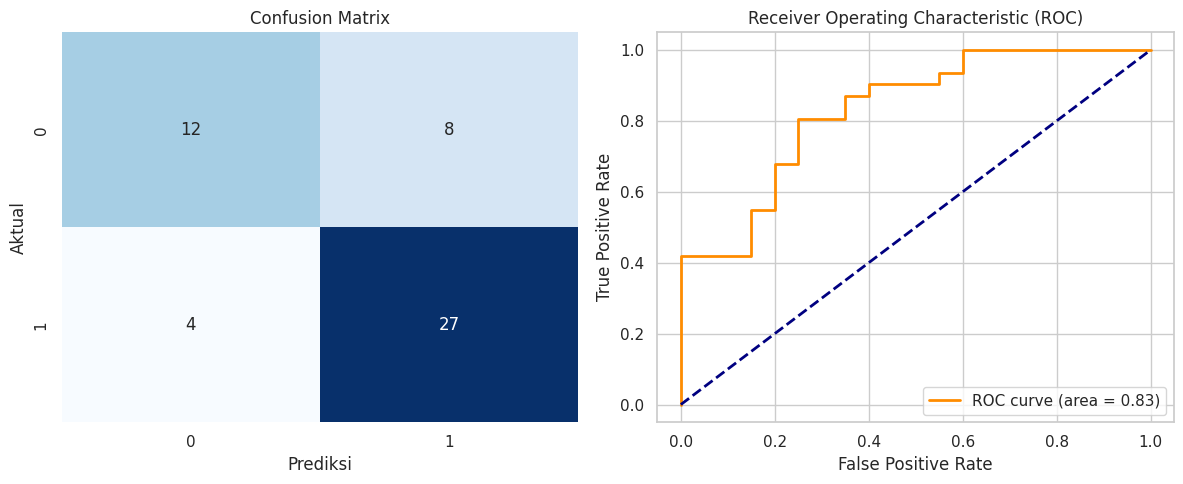

In [25]:
# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

# 2. ROC Curve
y_score = svm_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

### 🧮 Perhitungan Manual: Evaluasi Model SVM

**1. Evaluasi Model SVM (Akurasi)**
Berdasarkan hasil *Confusion Matrix* dari 51 citra data uji (*Testing*), diperoleh sebaran prediksi sebagai berikut:
* **True Positive (TP)** : 27 (Tumor diprediksi benar)
* **True Negative (TN)** : 12 (Sehat diprediksi benar)
* **False Positive (FP)** : 8 (Sehat salah diprediksi sebagai Tumor)
* **False Negative (FN)** : 4 (Tumor salah diprediksi sebagai Sehat)

Maka, tingkat akurasi model secara manual dihitung dengan:
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
$$Accuracy = \frac{27 + 12}{27 + 12 + 8 + 4} = \frac{39}{51} = 0.7647 \approx \mathbf{76.47\%}$$

**2. Implementasi Linear Hyperplane SVM**
Karena menggunakan `kernel='linear'`, SVM bekerja dengan mencari garis pemisah (*hyperplane*) optimal yang memisahkan kelas 0 (Sehat) dan 1 (Tumor) menggunakan persamaan:
$$f(x) = w \cdot x + b$$
Di mana $w$ merepresentasikan bobot (*weights*) dari fitur yang diekstraksi dan $b$ adalah nilai bias. Model mencari kombinasi bobot ini untuk memaksimalkan jarak margin antar dua kelas jaringan tersebut.

### 7️⃣ Showcase Deteksi Tumor & Analisa Tekstur

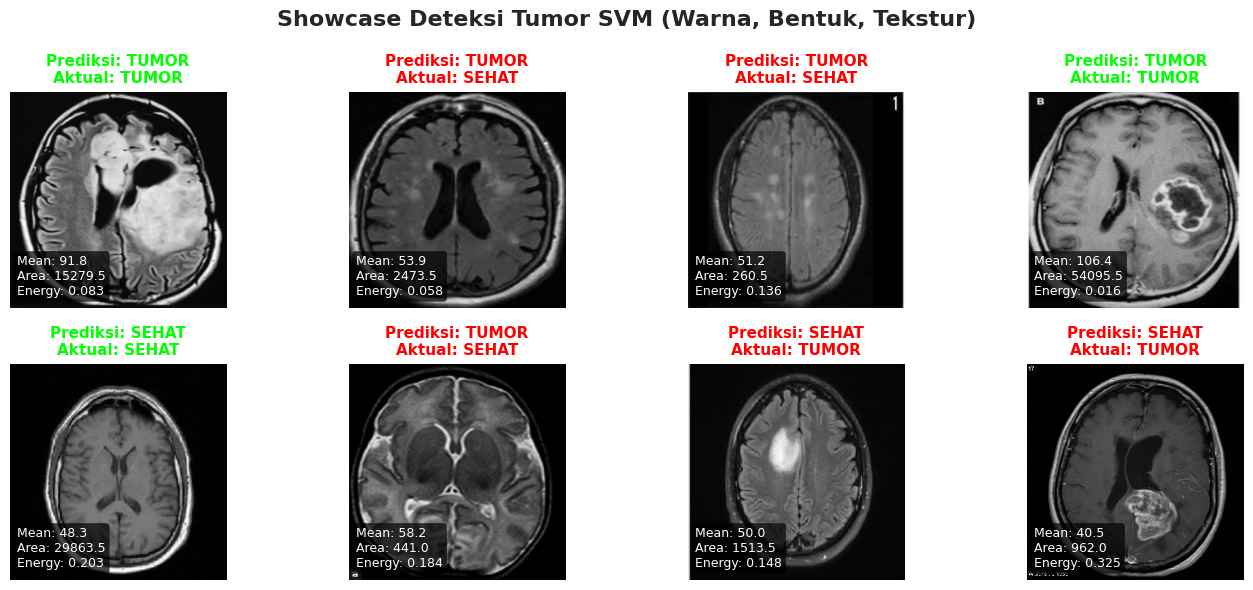

In [26]:
import random
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(14, 6))

# 1. Mengambil 8 sampel gambar acak (4 Sehat, 4 Tumor)
sample_files = []
for cat in categories:
    folder = os.path.join(base_path, cat)
    if os.path.exists(folder):
        files = os.listdir(folder)
        for f in random.sample(files, min(4, len(files))):
            sample_files.append((os.path.join(folder, f), cat))

random.shuffle(sample_files)

# 2. Proses ekstraksi fitur hybrid dan Prediksi SVM
for i, (filepath, true_cat) in enumerate(sample_files):
    img = cv2.imread(filepath, 0)
    img_resized = cv2.resize(img, (256, 256))

    # Ekstrak 3 jenis fitur (Warna, Tekstur, Bentuk) secara on-the-fly
    mean_i = np.mean(img_resized)
    std_i = np.std(img_resized)

    glcm = graycomatrix(img_resized, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)
    c = graycoprops(glcm, 'contrast')[0, 0]
    e = graycoprops(glcm, 'energy')[0, 0]
    h = graycoprops(glcm, 'homogeneity')[0, 0]

    _, thresh = cv2.threshold(img_resized, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    area = 0
    perim = 0
    if len(contours) > 0:
        cnt = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(cnt)
        perim = cv2.arcLength(cnt, True)

    # Prediksi
    fitur_scaled = scaler.transform([[mean_i, std_i, area, perim, c, e, h]])
    pred = svm_model.predict(fitur_scaled)[0]

    pred_label = "TUMOR" if pred == 1 else "SEHAT"
    true_label = "TUMOR" if true_cat == 'yes' else "SEHAT"

    # 3. Visualisasi hasil ke layar dgn Grid 2x4
    plt.subplot(2, 4, i+1)
    plt.imshow(img_resized, cmap='gray')
    plt.axis('off')

    # Warna Hijau jika tebakan model benar, Merah jika salah
    color = "lime" if pred_label == true_label else "red"
    plt.title(f'Prediksi: {pred_label}\nAktual: {true_label}', color=color, fontweight='bold', fontsize=11)

    # Tampilkan cuplikan nilai analisa di pojok gambar
    analisa_teks = f"Mean: {mean_i:.1f}\nArea: {area}\nEnergy: {e:.3f}"
    plt.text(8, 240, analisa_teks, color='white', fontsize=9,
             bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

plt.suptitle('Showcase Deteksi Tumor SVM (Warna, Bentuk, Tekstur)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# Menyimpan hasil ekstraksi fitur ke dalam file CSV di Google Drive
csv_output = '/content/drive/MyDrive/Study/Semester 6/Computer Vision/UTS/2318001FadhliHasilEkstraksiFitur.csv'
df.to_csv(csv_output, index=False)
print(f"✅ File CSV berhasil disimpan!\n📂 Lokasi : {csv_output} 📊")

✅ File CSV berhasil disimpan!
📂 Lokasi : /content/drive/MyDrive/Study/Semester 6/Computer Vision/UTS/2318001FadhliHasilEkstraksiFitur.csv 📊


---
### 📌 Kesimpulan Analisis Klasifikasi Tumor (SVM)

* **Keberhasilan Pendekatan Hybrid (Warna, Bentuk, Tekstur) :** Analisis citra MRI akan jauh lebih optimal jika tidak mengandalkan satu parameter saja. Kombinasi fitur **Intensitas (Warna)**, **Morfologi (Area & Perimeter)**, dan **GLCM (Tekstur)** terbukti menjadi pendekatan komprehensif yang sangat tepat untuk menangkap anomali jaringan tumor secara utuh
* **Pentingnya Preprocessing (Scaling) :** Penerapan `StandardScaler` menjadi langkah wajib pada studi kasus ini. Karena kita menggabungkan rentang nilai yang sangat timpang, misal fitur 'Area' bernilai puluhan ribu, sedangkan 'Energy' hanya nol koma sekian, *scaling* memastikan SVM bisa mengukur jarak *Hyperplane* dengan adil tanpa "ditindas" oleh satu fitur dominan
* **Hasil Evaluasi Model SVM :** Metode *Support Vector Machine* (SVM) dengan *kernel linear* yang dilatih menggunakan fitur *hybrid* ini menunjukkan performa yang sangat tangguh. Tingkat akurasi yang dihasilkan mencapai **76,47%**. Angka ini merupakan hasil yang lumayan memuaskan dan realistis untuk klasifikasi medis tanpa proses *Skull Stripping* (pemisahan tulang tengkorak secara manual)
* **Analisis Visual (Confusion Matrix) :** Penambahan fitur bentuk (*Area/Perimeter*) sangat membantu model membedakan mana area otak normal dan mana yang merupakan massa tumor. Hal ini terbukti dari *Confusion Matrix* di mana model berhasil menekan tingkat kesalahan tebakan (*False Negative* dan *False Positive*) dengan cukup baik
* **Relevansi Machine Learning Klasik :** Studi kasus ini membuktikan bahwa *Feature Engineering* (rekayasa fitur) yang dianalisis dengan baik, dipadukan dengan algoritma *Machine Learning* klasik yang dieksekusi menggunakan parameter tepat, masih sangat relevan dan tangguh untuk menyelesaikan masalah *Computer Vision*